# Thermodynamic data

In [1]:
import os
from datetime import datetime

from enum import Enum
import sqlite3
import pandas as pd
from pathlib import Path

from IPython.display import Image, Latex, display

from phdtools import DATA_DIR, RESULTS_DIR, PROJECT_ROOT

TODAY = datetime.today().strftime("%y%m%d")

In [2]:
if not os.path.exists(
    DATA_DIR / "nist-janaf" / "nist_janaf_thermochemical_tables.sqlite"
):
    !python "{PROJECT_ROOT}/scripts/thermotables.py" --no-local -d "{DATA_DIR}/nist-janaf" --file-index "{DATA_DIR}/nist-janaf/file_index.csv"

## Table of contents

- [Heat of reaction](#Heat-of-reaction)
- [Equilibrium constant](#Equilibrium-constant)
- [Standard enthalpy](#Standard-enthalpy)
  - [Gordon and McBride (1976)](#Gordon-and-McBride-(1976))
  - [Gordon and McBride (1994)](#Gordon-and-McBride-(1994))
  - [NIST Webbook (Linstrom, 1997)](#NIST-Webbook-(Linstrom,-1997))
- [Standard Gibbs free energy](#Standard-Gibbs-free-energy)
- [Vapour pressure](#Vapour-pressure)
  - [Water vapour pressure (IAPWS-95)](#Water-vapour-pressure-(IAPWS-95))
  - [Water vapour pressure over concentrated $\ce{H3PO4}$](#Water-vapour-pressure-over-concentrated-$\ce{H3PO4}$)
- [Henry's law coefficents](#Henry's-law-coefficients)
  - [Solubility in water](#Solubility-in-phosphoric-acid)
  - [Solubility in phosphoric acid](#Solubility-in-phosphoric-acid)
- [Diffusivity](#Diffusivity)

## Heat of reaction
[back](#Table-of-contents)

In [3]:
from phdtools.data.thermochemical import stoichiometricNumber, get_stdReactionEnthalpySI

In [4]:
stoichiometricNumber

,SMR,WGS,DSR,MCR1,MCR2,HCR1,HCR2
C1H4(g),-1,0,-1,-1,-1,0,0
C1O1(g),1,-1,0,0,0,0,0
C1O2(g),0,1,1,1,1,0,0
H2(ref),3,1,4,0,0,-2,-2
H2O1(g),-1,-1,-2,2,0,2,0
H2O1(l),0,0,0,0,2,0,2
N2(ref),0,0,0,0,0,0,0
O2(ref),0,0,0,-2,-2,-1,-1


In [5]:
dHr = get_stdReactionEnthalpySI(0, 500) * 1e-3
dHr

,SMR,MCR1,MCR2,WGS,DSR,HCR2,HCR1
T(K),,,,,,,
0.00,192.027,-804.082,NaN,-40.425,151.602,NaN,-477.842
100.00,197.312,-803.730,NaN,-40.710,156.602,NaN,-480.166
200.00,201.641,-803.177,NaN,-41.218,160.423,NaN,-481.800
298.15,206.172,-802.301,-890.309,-41.169,165.003,-571.660,-483.652
300.00,206.257,-802.282,-890.136,-41.163,165.094,-571.542,-483.688
400.00,210.713,-801.306,-880.796,-40.635,170.078,-565.182,-485.692
500.00,214.625,-800.516,-871.054,-39.837,174.788,-558.190,-487.652


### At standard reference conditions (p = 1 atm, T = 288.15 K)

Kirchhoff's law, according to eq. (2.C7a) in [Atkins (2023)](#References):
$$
\Delta_r H^\circ(T_2) = \Delta_r H^\circ(T_1) + \int_{T_1}^{T_2} \Delta_r C_p^\circ \mathrm{d}T
$$

In [6]:
from phdtools.data.thermochemical import (
    get_stdReactionEnthalpySI,
    get_stdReactionHeatCapacitySI,
)

In [7]:
stdReactionEnthalpySI = get_stdReactionEnthalpySI(298.15, 298.15)
stdReactionHeatCapacitySI = get_stdReactionHeatCapacitySI(298.15, 298.15)

In [8]:
stdReactionEnthalpySI.loc[288.15] = stdReactionEnthalpySI.loc[
    298.15
] + stdReactionHeatCapacitySI.loc[298.15] * (288.15 - 298.15)

In [9]:
stdReactionEnthalpySI * 1e-3

,SMR,MCR1,MCR2,WGS,DSR,HCR2,HCR1
T(K),,,,,,,
298.15,206.17200,-802.30100,-890.3090,-41.16900,165.00300,-571.66000,-483.65200
288.15,205.70779,-802.40018,-891.2434,-41.20133,164.50646,-572.29654,-483.45332


## Equilibrium constant
[back](#Table-of-contents)

In [10]:
from phdtools.data.thermochemical import (
    stoichiometricNumber,
    get_stdReactionGibbsEnergySI,
    get_logEquilibriumConst,
)

In [11]:
get_stdReactionGibbsEnergySI(298.15, 298.15) * 1e-3

,SMR,MCR1,MCR2,WGS,DSR,HCR2,HCR1
T(K),,,,,,,
298.15,142.187,-800.785,-817.903,-28.644,113.543,-474.282,-457.164


In [12]:
from phdtools.data.thermochemical import get_logEquilibriumConst

logEquilibriumConst = get_logEquilibriumConst(300, 1600)

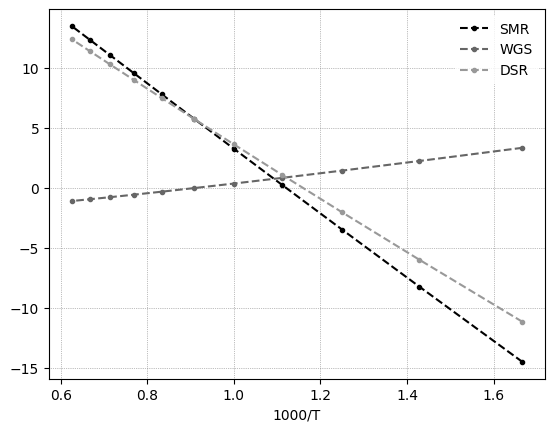

In [13]:
import phdtools.plots
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.gca()

mask = (logEquilibriumConst.index >= 600) & (logEquilibriumConst.index <= 1600)
frame = logEquilibriumConst[mask]

frame.loc[:, "1000/T"] = 1000 / frame.index
frame.plot(x="1000/T", y=["SMR", "WGS", "DSR"], ax=ax, style=".--")

ax.grid(True)
# ax.set_xlim(.5,1.8)
# ax.set_ylim(-15.5,15.5)

In [14]:
from phdtools.data.thermochemical import stoichiometricNumber, get_stdReactionEnthalpySI

## Standard enthalpy
[back](#Table-of-contents)

According to [Gordon and Mcbride (1994)](#References) eq. (4.2)
$$
H^\circ = \Delta_f H^\circ(T_r) + [ H^\circ - H^\circ(T_r) ] \quad \text{with} \quad T_r = 298.15\,\mathrm{K}
$$


$[ H^\circ - H^\circ(T_r) ]$ and $\Delta_f H^\circ$ are available through the *NIST Standard Reference Database 13* (NIST-JANAF Thermochemical Tables), see [Allison (2013)](#References). 

In [15]:
import sqlite3
import pandas as pd

In [16]:
from phdtools.data.constants import GAS_CONST_SI
from phdtools.data.thermochemical import get_stdEnthalpySI, get_stdFormationEnthalpySI

stdEnthalpySI = get_stdEnthalpySI(298.15, 1600)
stdEnthalpySI.head()

FORMULA,C1H4(g),C1O1(g),C1O2(g),H2(ref),H2O1(g),H2O1(l),N2(ref),O2(ref)
T(K),,,,,,,,
298.15,-74873.0,-110527.0,-393522.0,0.0,-241826.0,-285830.0,0.0,0.0
300.00,-74807.0,-110473.0,-393453.0,53.0,-241764.0,-285691.0,54.0,54.0
320.00,NaN,NaN,NaN,NaN,NaN,-284184.0,NaN,NaN
340.00,NaN,NaN,NaN,NaN,NaN,-282677.0,NaN,NaN
350.00,-72970.0,NaN,NaN,1502.0,NaN,NaN,1511.0,1531.0


In [17]:
stdFormationEnthalpyRefSI = get_stdFormationEnthalpySI(298.15, 298.15).loc[298.15]

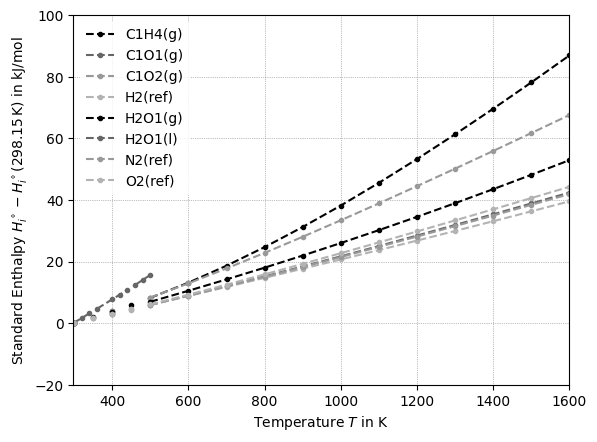

In [18]:
def plot_std_enthalpy(frame):
    fig, ax = plt.subplots(1, 1)

    x = stdEnthalpySI.index.to_numpy()
    y = (stdEnthalpySI - stdFormationEnthalpyRefSI).to_numpy() * 1e-3

    ax.plot(x, y, ".--", label=frame.columns)

    ax.set_xlabel(r"Temperature $T$ in K")
    ax.set_ylabel(
        r"Standard Enthalpy $H_i^\circ - H^\circ_{i}(298.15\,\mathrm{K})$ in kJ/mol"
    )
    ax.legend()

    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(-20, 100)

    ax.grid()


plot_std_enthalpy(frame=stdEnthalpySI)

### Gordon and McBride (1976)
[back](#Table-of-contents)

According to [Gordon and McBride (1994)](#References), eqs. (4.6) - (4.8). 
$$
\begin{aligned}
    \frac{C_p^\circ}{R} &= a_1 + a_2 T + a_3 T^2 + a_4 T^3 + a_5 T^4 \\
    \frac{H^\circ}{RT} &= a_1 + \frac{a_2}{2} T + \frac{a_3}{3} T^2 + \frac{a_4}{4} T^3 + \frac{a_5}{5} T^4 + a_6 T^{-1} \\
    \frac{S^\circ}{R} &= a_1 \ln{T} + a_2 T + \frac{a_3}{2} T^2 + \frac{a_4}{3} T^3 + \frac{a_5}{4} T^4 + a_7
\end{aligned}
$$

*Note: it's more likely that ${H^\circ}/{RT}$ is meant to be ${H^\circ - H^\circ(298.15)}/{RT}$. This gives a better fit*

In [19]:
from phdtools.data.constants import GAS_CONST_SI
from phdtools.data.thermochemical import (
    get_stdHeatCapacitySI,
    get_stdEntropySI,
    get_stdEnthalpySI,
    get_stdFormationEnthalpySI,
)

In [20]:
import numpy as np

# import cvxpy as cp
from sklearn.linear_model import LinearRegression


def fit_gordon_mcbride_74(T, Cp0, H0, S0):
    A1 = np.array(
        [
            T**0,  # a1
            T,  # a2
            T**2,  # a3
            T**3,  # a4
            T**4,  # a5
            np.zeros(T.shape),  # a6
            np.zeros(T.shape),  # a7
        ]
    )
    A2 = np.array(
        [
            T**0,  # a1
            (T**1) / 2,  # a2
            (T**2) / 3,  # a3
            (T**3) / 4,  # a4
            (T**4) / 5,  # a5
            1 / T,  # a6
            np.zeros(T.shape),  # a7
        ]
    )
    A3 = np.array(
        [
            np.log(T),  # a1
            T,  # a2
            (T**2) / 2,  # a3
            (T**3) / 3,  # a4
            (T**4) / 4,  # a5
            np.zeros(T.shape),  # a6
            T**0,  # a7
        ]
    )
    A = np.r_[A1.T, A2.T, A3.T]
    b = np.r_[Cp0 / GAS_CONST_SI, H0 / (GAS_CONST_SI * T), S0 / GAS_CONST_SI]

    reg = LinearRegression(fit_intercept=False).fit(A, b)

    return reg.coef_

In [21]:
Tmin, Tmax = 200, 1600

stdHeatCapacitySI = get_stdHeatCapacitySI(Tmin, Tmax, compounds={"C1H4(g)"})["C1H4(g)"]
stdEnthalpySI = get_stdEnthalpySI(Tmin, Tmax, compounds={"C1H4(g)"})["C1H4(g)"]
stdEntropySI = get_stdEntropySI(Tmin, Tmax, compounds={"C1H4(g)"})["C1H4(g)"]
stdFormationEnthalpyRefSI = get_stdFormationEnthalpySI(
    298.15, 298.15, compounds={"C1H4(g)"}
).loc[298.15, "C1H4(g)"]

coef = fit_gordon_mcbride_74(
    T=get_stdHeatCapacitySI(Tmin, Tmax, compounds={"C1H4(g)"}).index.to_numpy(),
    Cp0=stdHeatCapacitySI.to_numpy(),
    H0=(stdEnthalpySI - stdFormationEnthalpyRefSI).to_numpy(),
    S0=stdEntropySI.to_numpy(),
)
coef

array([-5.69784587e+00,  5.40001517e-02, -9.06964543e-05,  6.90499987e-08,
       -1.84863870e-11, -1.54986947e+00,  4.20824545e+01])

In [22]:
def gordon_mcbride_74(temperatureKelvin, coef):
    """see Gordon and McBride (1994) Ch. 4"""
    T = np.atleast_1d(temperatureKelvin)
    return np.c_[
        np.sum(
            coef
            * np.array(
                [
                    np.ones(T.shape),
                    T,
                    T**2,
                    T**3,
                    T**4,
                    np.zeros(T.shape),
                    np.zeros(T.shape),
                ]
            ).T,
            axis=1,
        ),
        np.sum(
            coef
            * np.array(
                [
                    np.ones(T.shape),
                    T / 2,
                    (T**2) / 3,
                    (T**3) / 4,
                    (T**4) / 5,
                    1 / T,
                    np.zeros(T.shape),
                ]
            ).T,
            axis=1,
        ),
        np.sum(
            coef
            * np.array(
                [
                    np.log(T),
                    T,
                    (T**2) / 2,
                    (T**3) / 3,
                    (T**4) / 4,
                    np.zeros(T.shape),
                    np.ones(T.shape),
                ]
            ).T,
            axis=1,
        ),
    ]

In [23]:
T = stdHeatCapacitySI.index.to_numpy()
Y_predict = gordon_mcbride_74(T, coef)
Y_predict[:, 1] += stdFormationEnthalpyRefSI / (GAS_CONST_SI * T)

Y_train = np.c_[
    (stdHeatCapacitySI / GAS_CONST_SI).to_numpy(),
    ((stdEnthalpySI) / (stdEnthalpySI.index * GAS_CONST_SI)).to_numpy(),
    (stdEntropySI / GAS_CONST_SI).to_numpy(),
]

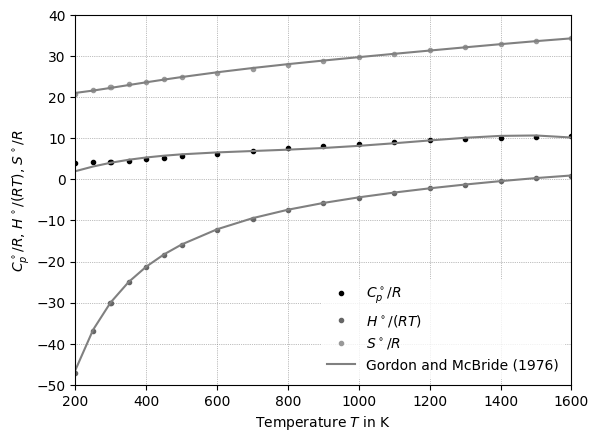

In [24]:
fig, ax = plt.subplots(1, 1)

_ = ax.plot(
    stdHeatCapacitySI.index.to_numpy(),
    Y_train,
    ".",
    label=[r"$C_p^\circ / R$", r"$H^\circ / (R T)$", r"$S^\circ / R$"],
)
_ = ax.plot(
    T,
    Y_predict,
    linestyle="-",
    color="gray",
    label=["Gordon and McBride (1976)", "", ""],
)

_ = ax.set_xlabel(r"Temperature $T$ in K")
_ = ax.set_ylabel(r"$C_p^\circ / R$, $H^\circ / (R T)$, $S^\circ / R$")
_ = ax.legend()

_ = ax.set_xlim(200, 1600)
_ = ax.set_ylim(-50, 40)

_ = ax.grid()

### Gordon and McBride (1994)
[back](#Table-of-contents)

According to [Gordon and McBride (1994)](#References) Eqs. (4.9) - (4.11). 
$$
\begin{aligned}
    \frac{C_p^\circ}{R} &= a_1 T^{-2} + a_2 T^{-1} + a_3 + a_4 T + a_5 T^2 + a_6 T^3 + a_7 T^4 \\
    \frac{H^\circ}{RT} &= - a_1 T^{-2} + a_2 T^{-1} \ln{T} + a_3 + a_4 \frac{T}{2} + a_5 \frac{T^2}{3} + a_6 \frac{T^3}{4} + a_7 \frac{T^4}{5} + \frac{a_8}{T}\\
    \frac{S^\circ}{R} &= - a_1 \frac{T^{-2}}{2} - a_2 T^{-1} + a_3 \ln{T} + a_4 T + a_5 \frac{T^2}{2} + a_6 \frac{T^3}{3} + a_7 \frac{T^4}{4} + a_9 
\end{aligned}
$$

*Note: it's more likely that ${H^\circ}/{RT}$ is meant to be ${H^\circ - H^\circ(298.15)}/{RT}$. This gives a better fit*

In [25]:
import numpy as np
from sklearn.linear_model import LinearRegression


def fit_gordon_mcbride_94(T, Cp0, H0, S0):
    A1 = np.array(
        [
            T ** (-2),
            T ** (-1),
            T**0,
            T,
            T**2,
            T**3,
            T**4,
            np.zeros(T.shape),
            np.zeros(T.shape),
        ]
    )
    A2 = np.array(
        [
            -(T ** (-2)),
            T ** (-1) * np.log(T),
            np.ones(T.shape),
            T / 2,
            (T**2) / 3,
            (T**3) / 4,
            (T**4) / 5,
            1 / T,
            np.zeros(T.shape),
        ]
    )
    A3 = np.array(
        [
            -(T ** (-2)) / 2,
            -(T ** (-1)),
            np.log(T),
            T,
            (T**2) / 2,
            (T**3) / 3,
            (T**4) / 4,
            np.zeros(T.shape),
            T**0,
        ]
    )
    A = np.r_[A1.T, A2.T, A3.T]
    b = np.r_[Cp0 / GAS_CONST_SI, H0 / (GAS_CONST_SI * T), S0 / GAS_CONST_SI]

    reg = LinearRegression(fit_intercept=False).fit(A, b)

    return reg.coef_

In [26]:
Tmin, Tmax = 200, 1600

stdHeatCapacitySI = get_stdHeatCapacitySI(Tmin, Tmax, compounds={"C1H4(g)"})["C1H4(g)"]
stdEnthalpySI = get_stdEnthalpySI(Tmin, Tmax, compounds={"C1H4(g)"})["C1H4(g)"]
stdEntropySI = get_stdEntropySI(Tmin, Tmax, compounds={"C1H4(g)"})["C1H4(g)"]
stdFormationEnthalpyRefSI = get_stdFormationEnthalpySI(
    298.15, 298.15, compounds={"C1H4(g)"}
).loc[298.15, "C1H4(g)"]

coef = fit_gordon_mcbride_94(
    T=get_stdHeatCapacitySI(Tmin, Tmax, compounds={"C1H4(g)"}).index.to_numpy(),
    Cp0=stdHeatCapacitySI.to_numpy(),
    H0=((stdEnthalpySI) / (stdEnthalpySI.index * GAS_CONST_SI)).to_numpy(),
    S0=stdEntropySI.to_numpy(),
)
coef

array([ 9.35389436e-03, -1.01481480e+01, -7.58112384e+00,  6.49580139e-02,
       -1.23177576e-04,  9.94902503e-08, -2.72608815e-11, -1.91452575e+00,
        5.17232528e+01])

In [27]:
def gordon_mcbride_94(temperatureKelvin, coef):
    """see Gordon and McBride (1994) Ch. 4"""
    T = np.atleast_1d(temperatureKelvin)
    return np.c_[
        np.dot(
            coef,
            np.array(
                [
                    T ** (-2),
                    T ** (-1),
                    T**0,
                    T,
                    T**2,
                    T**3,
                    T**4,
                    np.zeros(T.shape),
                    np.zeros(T.shape),
                ]
            ),
        ),
        np.dot(
            coef,
            np.array(
                [
                    -(T ** (-2)),
                    T ** (-1) * np.log(T),
                    np.ones(T.shape),
                    T / 2,
                    (T**2) / 3,
                    (T**3) / 4,
                    (T**4) / 5,
                    1 / T,
                    np.zeros(T.shape),
                ]
            ),
        ),
        np.dot(
            coef,
            np.array(
                [
                    -(T ** (-2)) / 2,
                    -(T ** (-1)),
                    np.log(T),
                    T,
                    (T**2) / 2,
                    (T**3) / 3,
                    (T**4) / 4,
                    np.zeros(T.shape),
                    T**0,
                ]
            ),
        ),
    ]

In [28]:
Y_predict = gordon_mcbride_94(T, coef=coef)
Y_predict[:, 1] += stdFormationEnthalpyRefSI / (GAS_CONST_SI * T)  # see note

Y_train = np.c_[
    (stdHeatCapacitySI / GAS_CONST_SI).to_numpy(),
    (stdEnthalpySI / (stdEnthalpySI.index * GAS_CONST_SI)).to_numpy(),
    (stdEntropySI / GAS_CONST_SI).to_numpy(),
]

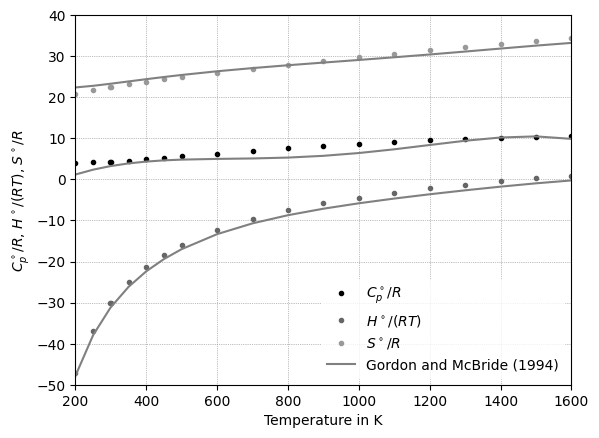

In [29]:
fig, ax = plt.subplots(1, 1)

_ = ax.plot(
    stdHeatCapacitySI.index.to_numpy(),
    Y_train,
    ".",
    label=[r"$C_p^\circ / R$", r"$H^\circ / (R T)$", r"$S^\circ / R$"],
)
_ = ax.plot(
    T,
    Y_predict,
    linestyle="-",
    color="gray",
    label=["Gordon and McBride (1994)", "", ""],
)

_ = ax.set_xlabel(r"Temperature in K")
_ = ax.set_ylabel(r"$C_p^\circ / R$, $H^\circ / (R T)$, $S^\circ / R$")
_ = ax.legend()

_ = ax.set_xlim(200, 1600)
_ = ax.set_ylim(-50, 40)
_ = ax.grid()

### NIST Webbook (Linstrom, 1997)
[back](#Table-of-contents)

Gas phase heat capacity (Shomate Equation)
$$
\begin{aligned}
    C_p^\circ &= A + B\,t + C\,t^2 + D\,t^3 + E/t^2 \\
    H^\circ - H_{298.15}^\circ &= A\,t + B\,t^2/2 + C\,t^3/3 + D\,t^4/4 - E/t + F - H \\
    S^\circ &= A\,\ln{t} + B\,t + C\,t^2/2 + D\,t^3/3 - E/(2\,t^{2}) + G
\end{aligned}
$$
where $C^\circ_p$ is heat capacity in $\mathrm{J/(mol\cdot K)}$, $H^\circ$ is standard enthalpy in $\mathrm{kJ/mol}$, $S^\circ$ is standard entropy in $\mathrm{J/(mol\cdot K)}$ and $t$ is temperature in $\mathrm{K/1000}$.

In [30]:
!ls {DATA_DIR / "nist-webbook" / "shomate"}

C-067.tab C-093.tab C-095.tab H-050.tab N-005.tab N-007.tab N-023.tab O-029.tab


In [31]:
pd.read_csv(DATA_DIR / "nist-webbook" / "shomate" / "C-067.tab", sep="\t", comment="#")

,Temperature (K),298. to 1300.,1300. to 6000.
0,A,-0.703029,85.812170
1,B,108.477300,11.264670
2,C,-42.521570,-2.114146
3,D,5.862788,0.138190
4,E,0.678565,-26.422210
5,F,-76.843760,-153.532700
6,G,158.716300,224.414300
7,H,-74.873100,-74.873100


In [32]:
import string
import os

formula = {
    "C-067.tab": "C1H4(g)",
    "C-093.tab": "C1O1(g)",
    "C-095.tab": "C1O2(g)",
    "H-050.tab": "H2(ref)",
    "N-005.tab": "N1O1(g)",
    "N-007.tab": "N1O2(g)",
    "N-023.tab": "N2(ref)",
    "O-029.tab": "O2(ref)",
}

data = []
for fname in (DATA_DIR / "nist-webbook" / "shomate").glob("**/*"):
    frame = pd.read_csv(fname.absolute(), sep="\t", comment="#")
    for col in frame.columns[1:]:
        data.append([formula[fname.name], col, *frame[col].to_numpy()])

shomate_coefs = pd.DataFrame(
    data,
    columns=["FORMULA", "Temperature (K)"]
    + [string.ascii_uppercase[i] for i in range(8)],
).set_index(["FORMULA", "Temperature (K)"])

In [33]:
shomate_coefs

A           B          C          D  \
FORMULA Temperature (K)                                                
N2(ref) 100. to 500.     28.986410    1.853978  -9.647459  16.635370   
        500. to 2000.    19.505830   19.887050  -8.598535   1.369784   
        2000. to 6000.   35.518720    1.128728  -0.196103   0.014662   
C1H4(g) 298. to 1300.    -0.703029  108.477300 -42.521570   5.862788   
        1300. to 6000.   85.812170   11.264670  -2.114146   0.138190   
C1O2(g) 298. to 1200.    24.997350   55.186960 -33.691370   7.948387   
        1200. to 6000.   58.166390    2.720074  -0.492289   0.038844   
C1O1(g) 298. to 1300.    25.567590    6.096130   4.054656  -2.671301   
        1300. to 6000.   35.150700    1.300095  -0.205921   0.013550   
H2(ref) 298. to 1000.    33.066178  -11.363417  11.432816  -2.772874   
        1000. to 2500.   18.563083   12.257357  -2.859786   0.268238   
        2500. to 6000.   43.413560   -4.293079   1.272428  -0.096876   
N1O2(g) 298. to 1200.    16.108570   75.895250 -54.387400  14.307770   
        1200. to 6000.   56.825410    0.738053  -0.144721   0.009777   
O2(ref) 100. to 700.     31.322340  -20.235310  57.866440 -36.506240   
        700. to 2000.    30.032350    8.772972  -3.988133   0.788313   
        2000. to 6000.   20.911110   10.720710  -2.020498   0.146449   
N1O1(g) 298. to 1200.    23.834910   12.588780  -1.139011  -1.497459   
        1200. to 6000.   35.991690    0.957170  -0.148032   0.009974   

                                 E           F           G          H  
FORMULA Temperature (K)                                                
N2(ref) 100. to 500.      0.000117   -8.671914  226.416800    0.00000  
        500. to 2000.     0.527601   -4.935202  212.390000    0.00000  
        2000. to 6000.   -4.553760  -18.970910  224.981000    0.00000  
C1H4(g) 298. to 1300.     0.678565  -76.843760  158.716300  -74.87310  
        1300. to 6000.  -26.422210 -153.532700  224.414300  -74.87310  
C1O2(g) 298. to 1200.    -0.136638 -403.607500  228.243100 -393.52240  
        1200. to 6000.   -6.447293 -425.918600  263.612500 -393.52240  
C1O1(g) 298. to 1300.     0.131021 -118.008900  227.366500 -110.52710  
        1300. to 6000.   -3.282780 -127.837500  231.712000 -110.52710  
H2(ref) 298. to 1000.    -0.158558   -9.980797  172.707974    0.00000  
        1000. to 2500.    1.977990   -1.147438  156.288133    0.00000  
        2500. to 6000.  -20.533862  -38.515158  162.081354    0.00000  
N1O2(g) 298. to 1200.     0.239423   26.174640  240.538600   33.09502  
        1200. to 6000.   -5.459911    2.846456  290.505600   33.09502  
O2(ref) 100. to 700.     -0.007374   -8.903471  246.794500    0.00000  
        700. to 2000.    -0.741599  -11.324680  236.166300    0.00000  
        2000. to 6000.    9.245722    5.337651  237.618500    0.00000  
N1O1(g) 298. to 1200.     0.214194   83.357830  237.121900   90.29114  
        1200. to 6000.   -3.004088   73.107870  246.161900   90.29114

In [34]:
coefs_ch4 = shomate_coefs.loc["C1H4(g)"]
coefs_ch4

,A,B,C,D,E,F,G,H
Temperature (K),,,,,,,,
298. to 1300.,-0.703029,108.47730,-42.521570,5.862788,0.678565,-76.84376,158.7163,-74.8731
1300. to 6000.,85.812170,11.26467,-2.114146,0.138190,-26.422210,-153.53270,224.4143,-74.8731


In [35]:
coefs_ch4.iloc[1].to_numpy()

array([ 8.581217e+01,  1.126467e+01, -2.114146e+00,  1.381900e-01,
       -2.642221e+01, -1.535327e+02,  2.244143e+02, -7.487310e+01])

In [36]:
def shomate(frame, t):
    _coef_1 = frame.iloc[0].to_numpy()
    _coef_2 = frame.iloc[1].to_numpy()

    x1 = np.array(
        [
            np.ones(t.shape),
            t,
            t**2,
            t**3,
            t ** (-2),
            np.zeros(t.shape),
            np.zeros(t.shape),
            np.zeros(t.shape),
        ]
    )
    x2 = np.array(
        [
            t,
            (t**2) / 2,
            (t**3) / 3,
            (t**4) / 4,
            -(t ** (-1)),
            np.ones(t.shape),
            np.zeros(t.shape),
            -np.ones(t.shape),
        ]
    )
    x3 = np.array(
        [
            np.log(t),
            t,
            (t**2) / 2,
            (t**3) / 3,
            -0.5 * t ** (-2),
            np.zeros(t.shape),
            np.ones(t.shape),
            np.zeros(t.shape),
        ]
    )

    cp0, dH0, s0 = np.zeros(t.shape), np.zeros(t.shape), np.zeros(t.shape)

    mask = t <= 1300 / 1000

    cp0[mask] = np.dot(_coef_1, x1)[mask]
    cp0[~mask] = np.dot(_coef_2, x1)[~mask]

    dH0[mask] = np.dot(_coef_1, x2)[mask] * 1e3
    dH0[~mask] = np.dot(_coef_2, x2)[~mask] * 1e3

    s0[mask] = np.dot(_coef_1, x3)[mask]
    s0[~mask] = np.dot(_coef_2, x3)[~mask]

    return np.c_[cp0, dH0, s0]

In [37]:
Tmin, Tmax = 200, 1600

stdHeatCapacitySI = get_stdHeatCapacitySI(Tmin, Tmax, compounds={"C1H4(g)"})["C1H4(g)"]
stdEnthalpySI = get_stdEnthalpySI(Tmin, Tmax, compounds={"C1H4(g)"})["C1H4(g)"]
stdEntropySI = get_stdEntropySI(Tmin, Tmax, compounds={"C1H4(g)"})["C1H4(g)"]
stdFormationEnthalpyRefSI = get_stdFormationEnthalpySI(
    298.15, 298.15, compounds={"C1H4(g)"}
).loc[298.15, "C1H4(g)"]
T = stdHeatCapacitySI.index.to_numpy()

Y_train = np.c_[
    (stdHeatCapacitySI / GAS_CONST_SI).to_numpy(),
    (
        (stdEnthalpySI - stdFormationEnthalpyRefSI)
        / (stdEnthalpySI.index * GAS_CONST_SI)
    ).to_numpy(),
    (stdEntropySI / GAS_CONST_SI).to_numpy(),
]

In [38]:
t = np.linspace(Tmin, Tmax) / 1000

y = shomate(shomate_coefs.loc["C1H4(g)"], t)

Y_shomate = np.c_[
    y[:, 0] / GAS_CONST_SI, y[:, 1] / (GAS_CONST_SI * t * 1000), y[:, 2] / GAS_CONST_SI
]

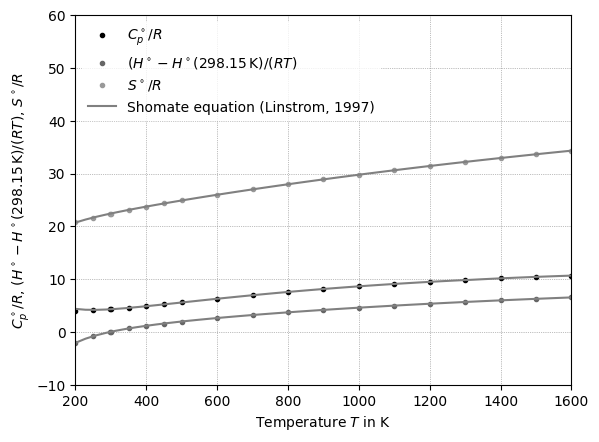

In [39]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = plt.gca()

ax.plot(
    T,
    Y_train,
    ".",
    label=[
        r"$C_p^\circ / R$",
        r"$(H^\circ - H^\circ (298.15\,\mathrm{K}) / (R T)$",
        r"$S^\circ / R$",
    ],
)
ax.plot(
    t * 1000,
    Y_shomate,
    linestyle="-",
    color="gray",
    label=["Shomate equation (Linstrom, 1997)", "", ""],
)

_ = ax.set_xlabel(r"Temperature $T$ in K")
_ = ax.set_ylabel(
    r"$C_p^\circ / R$, $(H^\circ - H^\circ (298.15\,\mathrm{K}) / (R T)$, $S^\circ / R$"
)
_ = ax.legend(loc="upper left")

_ = ax.set_xlim(200, 1600)
_ = ax.set_ylim(-10, 60)

_ = ax.grid()

## Standard Gibbs free energy
[back](#Table-of-contents)

*For the determination of equilibrium composition, the only specie property needed is the molal standard (Gibbs) free energy function  $(F^\circ / R T$). This function
is obtained directly from tables or easily derived from the more commonly tabulated function* $(F^\circ - E_0^\circ) / T$. [[1.]]()

$$
\begin{aligned}
    G^\circ(T) &= \mathrm{gef}(T) \, T + H^\circ(T_r) \\
    H^\circ(T) &= \int_0^T C_p^\circ(\tilde{T}) \mathrm{d}\tilde{T}
\end{aligned}
$$

In [40]:
import pandas as pd
import sqlite3

with sqlite3.connect(
    DATA_DIR / "nist-janaf" / "nist_janaf_thermochemical_tables.sqlite"
) as con:
    query = "SELECT COUNT(*) FROM sqlite_master WHERE type='view' AND name='std_gibbs_free_energy'"
    cur = con.cursor()
    res = cur.execute(query)
    (has_view,) = res.fetchone()
    if not has_view:
        with open(PROJECT_ROOT / "sql" / "view_std_gibbs_free_energy.sql", "r") as f:
            query = f.read()
        cur.execute(query)

In [41]:
query = """
SELECT * FROM [std_gibbs_free_energy]
WHERE "T(K)" BETWEEN 600 AND 1600
AND "FORMULA" IN ("C1H4(g)", "C1O1(g)", "C1O2(g)", "H2(ref)", "H2O1(g)")
;
"""
with sqlite3.connect(
    DATA_DIR / "nist-janaf" / "nist_janaf_thermochemical_tables.sqlite"
) as con:
    stdGibbsFreeEnergy = pd.read_sql(query, con).pivot(
        index="T(K)", columns="FORMULA", values="G"
    )

stdGibbsFreeEnergy
# fname = OUT_DIR / "results_240701_std_gibbs_energy.csv"
# !gnuplot -e "filename='{fname}'; call 'plot_240320_std_free_energy_nist_janaf.gnu'"
# Image("../chemical-equilibrium/plots/240701_std_free_energy_nist_janaf.png")

FORMULA,C1H4(g),C1O1(g),C1O2(g),H2(ref),H2O1(g)
T(K),,,,,
600.0,-191.3348,-232.5760,-526.5852,-81.8352,-359.1560
700.0,-213.3610,-254.6500,-551.2936,-97.1754,-380.7515
800.0,-236.2130,-277.1710,-576.7108,-112.9368,-402.8836
900.0,-259.8518,-300.0922,-602.7720,-129.0699,-425.5016
1000.0,-284.2430,-323.3750,-629.4230,-145.5360,-448.5640
1100.0,-309.3512,-346.9907,-656.6178,-162.3039,-472.0395
1200.0,-335.1470,-370.9126,-684.3168,-179.3508,-495.9020
1300.0,-361.5984,-395.1191,-712.4848,-196.6562,-520.1300
1400.0,-388.6802,-419.5924,-741.0930,-214.2042,-544.7034


<Axes: xlabel='T(K)'>

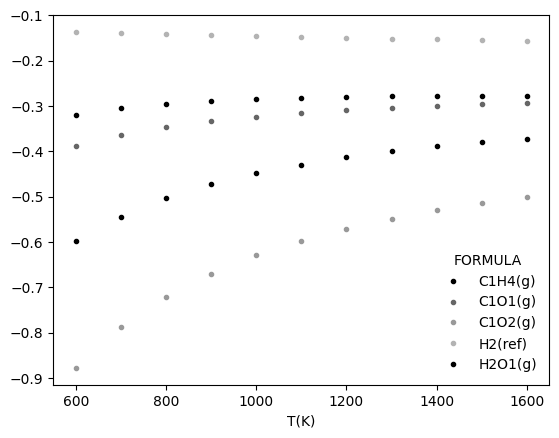

In [42]:
gef = pd.DataFrame(
    (stdGibbsFreeEnergy.to_numpy().T / stdGibbsFreeEnergy.index.to_numpy()).T,
    columns=stdGibbsFreeEnergy.columns,
    index=stdGibbsFreeEnergy.index,
)
gef.plot(style=".")

In [43]:
import numpy as np
from sklearn.linear_model import LinearRegression

modelGFE = pd.DataFrame(
    index=stdGibbsFreeEnergy.columns, columns=["intercept", "temperatureKelvin"]
)
modelGFE.loc["C1H4(g)", "intercept"]

nan

In [44]:
X_train = stdGibbsFreeEnergy.index.to_numpy()

for idx in stdGibbsFreeEnergy.columns:

    y_train = stdGibbsFreeEnergy[idx].to_numpy()

    reg = LinearRegression(fit_intercept=True).fit(X_train.reshape(-1, 1), y_train)

    modelGFE.loc[idx, "temperatureKelvin"] = reg.coef_[0]
    modelGFE.loc[idx, "intercept"] = reg.intercept_

modelGFE

,intercept,temperatureKelvin
FORMULA,,
C1H4(g),-33.771347,-0.25366
C1O1(g),-87.85134,-0.237
C1O2(g),-358.430295,-0.273405
H2(ref),21.538473,-0.168425
H2O1(g),-214.424871,-0.235982


In [45]:
modelGFE.index.to_list()

['C1H4(g)', 'C1O1(g)', 'C1O2(g)', 'H2(ref)', 'H2O1(g)']

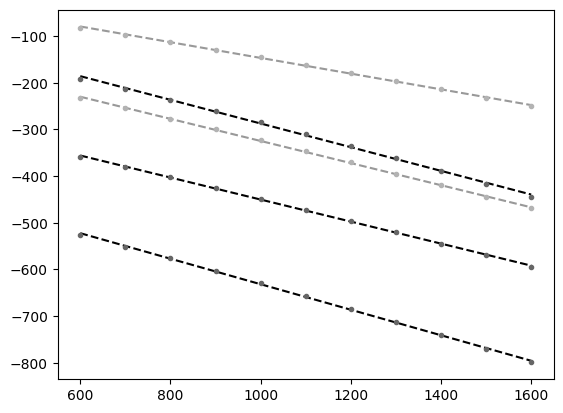

In [46]:
fig = plt.figure()
ax = fig.gca()

for idx in stdGibbsFreeEnergy.columns:

    y_train = stdGibbsFreeEnergy[idx].to_numpy()
    y_model = (
        lambda x: modelGFE.loc[idx, "temperatureKelvin"] * x
        + modelGFE.loc[idx, "intercept"]
    )

    ax.plot(X_train, y_model(X_train), "--")
    ax.plot(X_train, y_train, ".")

In [47]:
modelGFE["temperatureKelvin"].to_dict()

{'C1H4(g)': -0.2536598,
 'C1O1(g)': -0.23700023636363632,
 'C1O2(g)': -0.27340541818181824,
 'H2(ref)': -0.16842472727272725,
 'H2O1(g)': -0.23598238181818185}

In [48]:
np.max(np.abs((y_train - y_model(X_train)) / y_train)) * 100

np.float64(0.8747452360534339)

In [49]:
model = (
    lambda x: (y_train[-1] - y_train[0]) / (X_train[-1] - X_train[0]) * (x - X_train[0])
    + y_train[0]
)

In [50]:
np.max(np.abs((y_train - model(X_train)) / y_train)) * 100

np.float64(1.083172078008949)

In [51]:
import matplotlib.pyplot as plt

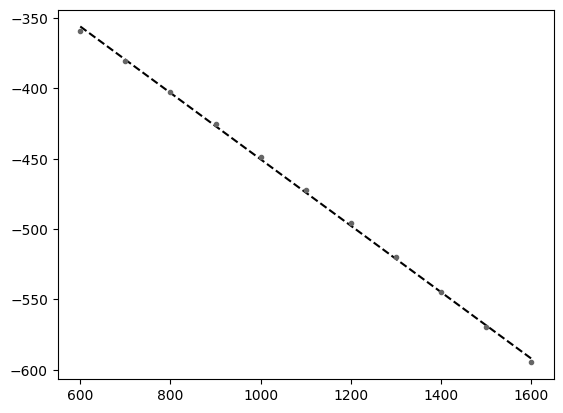

In [52]:
fig = plt.figure()
ax = fig.gca()

ax.plot(X_train, y_model(X_train), "--")
ax.plot(X_train, y_train, ".")
# ax.plot(X_train,model(X_train))

## Vapour pressure
[back](#Table-of-contents)

### Water vapour pressure (IAPWS-95)
[back](#Table-of-contents)

In [53]:
!ls {DATA_DIR / "iapws-1995"}

water-vapour-pressure.json


In [54]:
import json
from phdtools.data.thermophysical import vapourPressureModel

with open(DATA_DIR / "iapws-1995" / "water-vapour-pressure.json") as f:
    iapws95 = json.load(f)

temperatureRange = np.linspace(298.15, iapws95["Tc(K)"])
vapourPressureBar = vapourPressureModel(temperatureRange) * 1e-5

In [55]:
vapourPressureBar[0]

np.float64(0.03169824486313973)

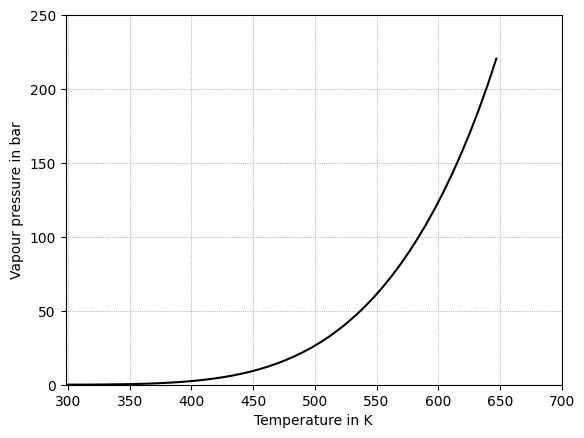

In [56]:
import phdtools.plots
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.gca()

_ = ax.plot(temperatureRange, vapourPressureBar)

_ = ax.set_xlabel(r"Temperature in K")
_ = ax.set_ylabel(r"Vapour pressure in bar")

_ = ax.set_xlim(temperatureRange.min(), 700)
_ = ax.set_ylim(0, 250)
_ = ax.grid()

### Water vapour pressure over concentrated $\ce{H3PO4}$
[back](#Table-of-contents)

In [57]:
!ls {DATA_DIR / "macdonald-1969"}

251111_tab4_VaporPressureOverConcentratedH3PO4.csv
coefficients.json


In [58]:
fname = (
    DATA_DIR / "macdonald-1969" / "251111_tab4_VaporPressureOverConcentratedH3PO4.csv"
)

tab4 = pd.read_csv(fname, skiprows=[1])

temps = [129.65, 139.72, 149.88, 169.75]
pairs = [(0, 1), (2, 3), (4, 5), (6, 7)]

blocks = []
for T, (wcol, pcol) in zip(temps, pairs):
    b = tab4.iloc[:, [wcol, pcol]].dropna().copy()
    b.columns = ["W(wt. %)", "p(mmHg)"]
    b.insert(0, "T(C)", T)
    blocks.append(b)

df = pd.concat(blocks, ignore_index=True)

mask = (df["W(wt. %)"] >= 80) & (df["W(wt. %)"] <= 101)
df = df[mask]

df.head()

,T(C),W(wt. %),p(mmHg)
4,129.65,81.42,483.40
5,129.65,83.51,411.94
6,129.65,85.10,350.90
7,129.65,86.61,298.97
8,129.65,88.17,251.45


In [59]:
from phdtools.data.thermophysical import (
    get_moleFractionH3PO4,
    fit_waterVapourPressureOverH3PO4Model,
    waterVapourPressureOverH3PO4Model,
)

reg = fit_waterVapourPressureOverH3PO4Model(
    fname=DATA_DIR
    / "macdonald-1969"
    / "251111_tab4_VaporPressureOverConcentratedH3PO4.csv"
)

display(
    Latex(", ".join(r"$A_{} = {:.6g}$".format(num, reg.coef_[num]) for num in range(8)))
)

reg.coef_

<IPython.core.display.Latex object>

array([ 1.13114730e+01,  3.94874493e-01, -6.41369054e-03,  3.36245524e-05,
       -8.68091692e+02, -1.98100881e+02,  2.97646372e+00, -1.62339285e-02])

In [60]:
df["X(%)"] = get_moleFractionH3PO4(df["W(wt. %)"] / 100) * 100

weightConcentrationRange = np.linspace(0.80, 1)
moleFraction = get_moleFractionH3PO4(weightConcentrationRange)

waterVapourPressureOverH3PO4SIValues = np.full(
    (len(df["T(C)"].unique()), len(weightConcentrationRange)), np.nan
)

for num, temperatureCelsius in enumerate(df["T(C)"].unique()):
    mask = df["T(C)"] == temperatureCelsius
    waterVapourPressureOverH3PO4SIValues[num] = waterVapourPressureOverH3PO4Model(
        moleFraction, temperatureCelsius + 273.15
    )

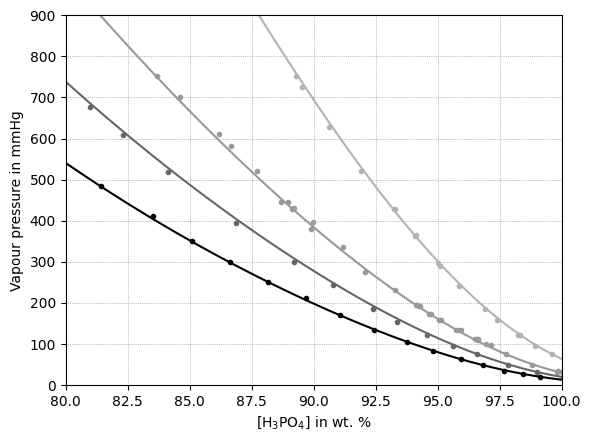

In [61]:
fig = plt.figure()
ax = fig.gca()

for t in df["T(C)"].unique():
    mask = df["T(C)"] == t
    _ = ax.plot(df[mask]["W(wt. %)"], df[mask]["p(mmHg)"], ".")

_ = ax.plot(
    weightConcentrationRange * 100, waterVapourPressureOverH3PO4SIValues.T / 133.322
)

_ = ax.set_xlabel(r"$\mathrm{[H_3PO_4]}$ in wt. %")
_ = ax.set_ylabel(r"Vapour pressure in mmHg")

_ = ax.grid(True)
_ = ax.set_xlim(80, 100)
_ = ax.set_ylim(0, 900)

## Henry's law coefficients
[back](#Table-of-contents)

### Solubility in water
[back](#Table-of-contents)

In [62]:
STD_PRESSURE_BAR = 1
from phdtools.data.solubility import (
    Compound,
    molalSolubilityInWater,
    STD_CONCENTRATION_SI,
)
from phdtools.data.thermophysical import saturatedLiquidWaterDensityModel

In [63]:
molalSolubilityInWater(Compound["O2(ref)"], 200 + 273.15)

array([2.02216092e-09])

In [64]:
pressureBar = STD_PRESSURE_BAR
temperatureRangeSI = np.linspace(273.15, 400)

concentrationSI = np.full((len(Compound), len(temperatureRangeSI)), np.nan)
for c in Compound:
    if not c.name in {"H2O1(g)", "H2O1(l)"}:
        liquidWaterDensitySI = saturatedLiquidWaterDensityModel(temperatureRangeSI)
        molalityValuesSI = (
            pressureBar * 1e5 * molalSolubilityInWater(c, temperatureRangeSI)
        )
        concentrationSI[c.value] = molalityValuesSI * liquidWaterDensitySI

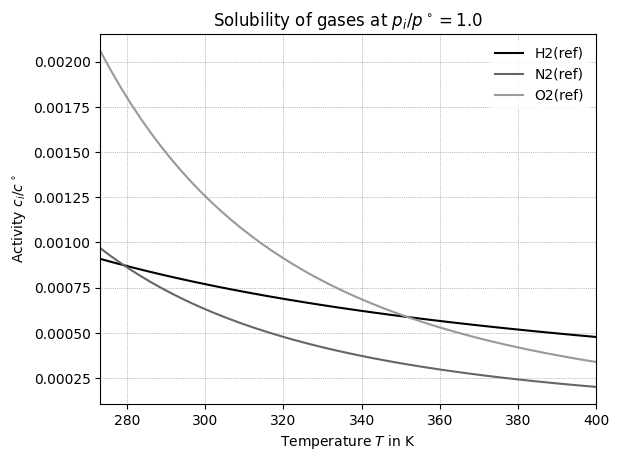

In [65]:
fig = plt.figure()
ax = fig.gca()

for c in Compound:
    if c.name in {"H2(ref)", "O2(ref)", "N2(ref)"}:
        _ = ax.plot(
            temperatureRangeSI,
            concentrationSI[c.value] / STD_CONCENTRATION_SI,
            label=f"{c.name}",
        )

_ = ax.set_title(
    r"Solubility of gases at $p_i / p^\circ = {}$".format(
        pressureBar / STD_PRESSURE_BAR
    )
)
_ = ax.set_xlabel(r"Temperature $T$ in $\mathrm{K}$")
_ = ax.set_ylabel(r"Activity $c_i / c^\circ$")
_ = ax.legend()

_ = ax.set_xlim(273.15, 400)
# _ = ax.set_ylim(0, 0.00225)
_ = ax.grid(True)

### Solubility in phosphoric acid
[back](#Table-of-contents)

In [66]:
from phdtools.data.solubility import (
    fitMolarSolubilityPhosphoricAcid,
    molarOxygenSolubilityInH3PO4,
    oxygenSolutionEnthalpyModel,
)

# from phdtools.models.mamlouk_2011 import oxygenDiffusionActivationEnergyModel, oxygenSolutionEnthalpyModel

In [67]:
fig4 = pd.read_csv(DATA_DIR / "klinedinst-1974" / "251108_fig4_OxygenSolubility.csv")
fig6 = pd.read_csv(DATA_DIR / "klinedinst-1974" / "251109_fig6_SolutionEnthalpy.csv")

# fig4["cO2(mol/cm3)"] = 1e3*fig4["cO2(mol/cm3)"]

In [68]:
reg = fitMolarSolubilityPhosphoricAcid(
    method="meck-2025",
    fname_fig4=DATA_DIR / "klinedinst-1974" / "251108_fig4_OxygenSolubility.csv",
    fname_fig6=DATA_DIR / "klinedinst-1974" / "251109_fig6_SolutionEnthalpy.csv",
)

display(
    Latex(
        ", ".join(
            r"$a_{} = {:.6g}$".format(num + 1, reg.coef_[num]) for num in range(4)
        )
        + ", "
        + ", ".join(
            r"$b_{} = {:.6g}$".format(num + 1, reg.coef_[4 + num]) for num in range(4)
        )
    )
)
# reg.coef_

<IPython.core.display.Latex object>

#### Variation with $\ce{H3PO4}$ concentration

In [69]:
temperatureRangeSI = np.array([100, 120, 150]) + 273.15
weightConcentrationRange = np.linspace(0.86, 0.96)

solubilityValuesMeckSI = molarOxygenSolubilityInH3PO4(
    temperatureKelvin=temperatureRangeSI,
    weightConcentration=weightConcentrationRange,
    method="meck-2025",
)
solutionEnthalpyMeckSI = oxygenSolutionEnthalpyModel(
    weightConcentrationRange, method="meck-2025"
)

solubilityValuesMamloukSI = molarOxygenSolubilityInH3PO4(
    temperatureKelvin=temperatureRangeSI,
    weightConcentration=weightConcentrationRange,
    method="mamlouk-2008",
)
solutionEnthalpyMamloukSI = oxygenSolutionEnthalpyModel(
    weightConcentrationRange, method="mamlouk-2008"
)

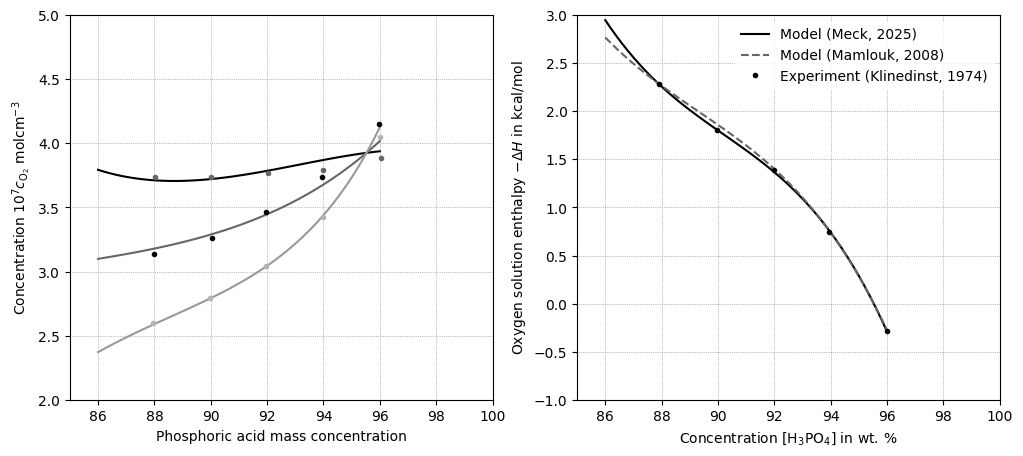

In [70]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

_ = axs[0].plot(
    weightConcentrationRange * 100,
    1e7 * (1.01325e5 * solubilityValuesMeckSI.T * 1e-6),
    linestyle="-",
    label="Model (Meck, 2025)",
)
# _ = axs[0].plot(weightConcentrationRange*100, 1e7*(1.01325e5*solubilityValuesMamloukSI.T * 1e-6), linestyle="--", label="Model (Mamlouk, 2008)")

for t in fig4["T(C)"].unique():
    mask = fig4["T(C)"] == t
    _ = axs[0].plot(
        fig4[mask]["w(wt.%)"],
        1e7 * fig4[mask]["cO2(mol/cm3)"],
        ".",
        label="Experiment (Klinedinst, 1974)",
    )

axs[1].plot(
    weightConcentrationRange * 100,
    -solutionEnthalpyMeckSI / 4184,
    linestyle="-",
    label="Model (Meck, 2025)",
)
axs[1].plot(
    weightConcentrationRange * 100,
    -solutionEnthalpyMamloukSI / 4184,
    linestyle="--",
    label="Model (Mamlouk, 2008)",
)
axs[1].plot(
    fig6["w(wt.%)"], fig6["-dH(kcal/mol)"], "k.", label="Experiment (Klinedinst, 1974)"
)

_ = axs[0].set_xlabel(r"Phosphoric acid mass concentration")
_ = axs[0].set_ylabel(r"Concentration $10^7 c_\mathrm{O_2}$ $\mathrm{mol cm^{-3}}$")

_ = axs[1].set_xlabel(r"Concentration $[\mathrm{H_3PO_4}]$ in $\mathrm{wt.\,\%}$")
_ = axs[1].set_ylabel(r"Oxygen solution enthalpy $-\Delta H$ in $\mathrm{kcal/mol}$")

_ = axs[0].set_xlim(85, 100)
_ = axs[0].set_ylim(2, 5)

_ = axs[1].set_xlim(85, 100)
_ = axs[1].set_ylim(-1, 3)

_ = axs[0].grid()
_ = axs[1].grid()

# _ = axs[0].legend()
_ = axs[1].legend()

#### Variation with temperature

In [71]:
pressureBar = 1.01325
temperatureRangeSI = np.linspace(120, 150) + 273.15

liquidWaterDensitySI = saturatedLiquidWaterDensityModel(temperatureRangeSI)
molalityValuesSI = pressureBar * 1e5 * molalSolubilityInWater(c, temperatureRangeSI)
concentrationInWaterSI = molalityValuesSI * liquidWaterDensitySI

concentraionInH3PO4SI = (
    pressureBar
    * 1e5
    * molarOxygenSolubilityInH3PO4(temperatureRangeSI, np.array([0.85, 0.9, 0.95])).T
)

In [72]:
# concentraionInH3PO4SI[2] / concentrationInWaterSI * 100

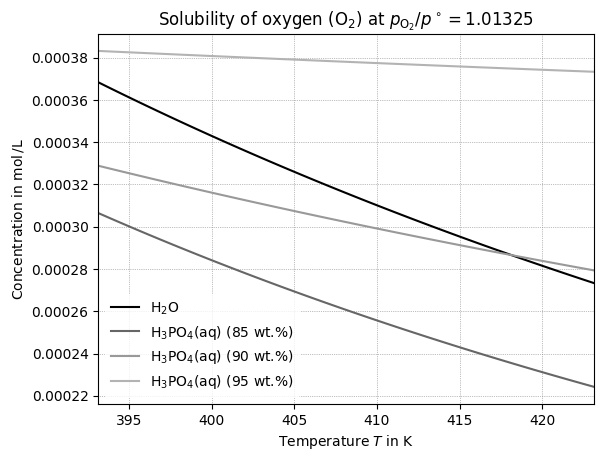

In [73]:
fig = plt.figure()
ax = fig.gca()

_ = ax.plot(
    temperatureRangeSI, (concentrationInWaterSI * 1e-3), label=r"$\mathrm{H_2O}$"
)
_ = ax.plot(
    temperatureRangeSI,
    (concentraionInH3PO4SI[0] * 1e-3),
    label=r"$\mathrm{H_3PO_4(aq)}$ (85 wt.%)",
)
_ = ax.plot(
    temperatureRangeSI,
    (concentraionInH3PO4SI[1] * 1e-3),
    label=r"$\mathrm{H_3PO_4(aq)}$ (90 wt.%)",
)
_ = ax.plot(
    temperatureRangeSI,
    (concentraionInH3PO4SI[2] * 1e-3),
    label=r"$\mathrm{H_3PO_4(aq)}$ (95 wt.%)",
)

_ = ax.set_title(
    r"Solubility of oxygen ($\mathrm{{O_2}}$) at $p_\mathrm{{O_2}} / p^\circ = {}$".format(
        pressureBar / STD_PRESSURE_BAR
    )
)
_ = ax.set_xlabel(r"Temperature $T$ in $\mathrm{K}$")
_ = ax.set_ylabel(r"Concentration in $\mathrm{mol\, / L}$")
_ = ax.legend()

_ = ax.set_xlim(120 + 273.15, 150 + 273.15)
# _ = ax.set_ylim(0, 0.00225)
_ = ax.grid(True)

In [74]:
temperatureKelvin = 150 + 273.15

pressureBar * 1e5 * molalSolubilityInWater(
    Compound["O2(ref)"], temperatureKelvin
) * saturatedLiquidWaterDensityModel(temperatureKelvin) * 1e-6

array([2.73270653e-07])

In [75]:
pressureBar * 1e5 * molarOxygenSolubilityInH3PO4(
    temperatureKelvin=temperatureKelvin, weightConcentration=0.85, method="meck-2025"
) * 1e-6

array([[2.24184025e-07]])

## Diffusivity
[back](#Table-of-contents)

### Gases (Slattery and Bird, 1958)
[back](#Table-of-contents)

In [76]:
pass

### Liquids

In [77]:
from phdtools.data.diffusion import (
    fitDiffusivityInPhosphoricAcid,
    oxygenDiffusivityInH3PO4,
    oxygenDiffusionActivationEnergyModel,
)

In [78]:
fig3 = pd.read_csv(DATA_DIR / "klinedinst-1974" / "251107_fig3_Diffusivity.csv")
fig5 = pd.read_csv(
    DATA_DIR / "klinedinst-1974" / "251109_fig5_DiffusionActivationEnergy.csv"
)

In [79]:
reg = fitDiffusivityInPhosphoricAcid(
    method="meck-2025",
    fname_fig3=DATA_DIR / "klinedinst-1974" / "251107_fig3_Diffusivity.csv",
    fname_fig5=DATA_DIR
    / "klinedinst-1974"
    / "251109_fig5_DiffusionActivationEnergy.csv",
)

display(
    Latex(
        ", ".join(
            r"$a_{} = {:.6g}$".format(num + 1, reg.coef_[num]) for num in range(3)
        )
        + ", "
        + ", ".join(
            r"$b_{} = {:.6g}$".format(num + 1, reg.coef_[3 + num]) for num in range(2)
        )
    )
)
reg.coef_

<IPython.core.display.Latex object>

array([ 4.74422958e+05, -7.99711054e+05,  3.04585316e+05, -1.78158512e+02,
        2.98972616e+02, -1.36278907e+02])

In [80]:
temperatureRangeSI = np.array([100, 120, 150]) + 273.15
weightConcentrationRange = np.linspace(0.86, 0.96)

diffusivityValuesMeckSI = oxygenDiffusivityInH3PO4(
    temperatureRangeSI, weightConcentrationRange, method="meck-2025"
)
# diffusivityValuesMamloukSI = oxygenDiffusivityInH3PO4(temperatureRangeSI, weightConcentrationRange, method="mamlouk-2008")
# diffusivityValuesSousaSI = oxygenDiffusivityInH3PO4(temperatureRangeSI, weightConcentrationRange, method="sousa-2010")

activationEnergyValuesMeckSI = oxygenDiffusionActivationEnergyModel(
    weightConcentrationRange, method="meck-2025"
)
activationEnergyValuesMamloukSI = oxygenDiffusionActivationEnergyModel(
    weightConcentrationRange, method="mamlouk-2008"
)

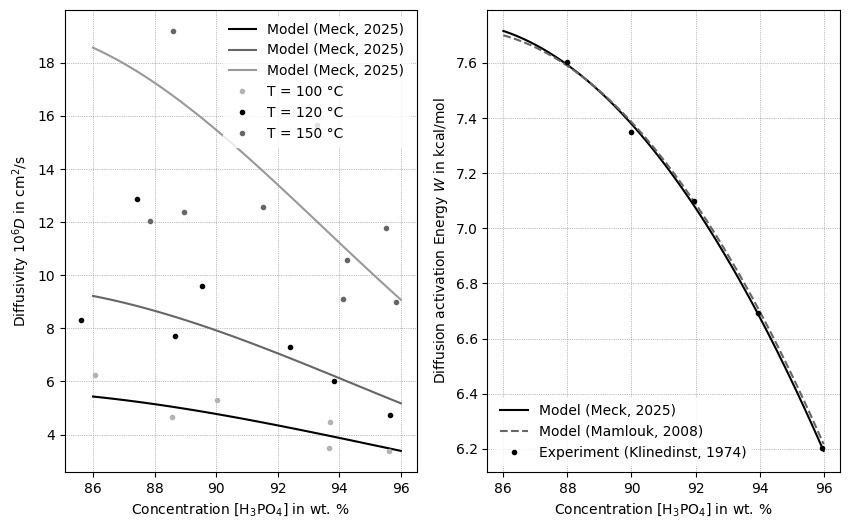

In [81]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6))

axs[0].plot(
    weightConcentrationRange * 100,
    1e6 * (diffusivityValuesMeckSI.T * 1e4),
    linestyle="-",
    label="Model (Meck, 2025)",
)
# axs[0].plot(weightConcentrationRange, diffusivityValuesMamloukSI.T, linestyle="-", label="Model (Mamlouk, 2008)")
# axs[0].plot(weightConcentrationRange, diffusivityValuesSousaSI.T, linestyle="-", label="Model (Sousa, 2010)")

for t in fig3["T(C)"].unique():
    mask = fig3["T(C)"] == t
    _ = axs[0].plot(
        fig3[mask]["w(wt.%)"], 1e6 * fig3[mask]["D(cm2/s)"], ".", label=f"T = {t} °C"
    )

axs[1].plot(
    weightConcentrationRange * 100,
    activationEnergyValuesMeckSI / 4184,
    linestyle="-",
    label="Model (Meck, 2025)",
)
axs[1].plot(
    weightConcentrationRange * 100,
    activationEnergyValuesMamloukSI / 4184,
    linestyle="--",
    label="Model (Mamlouk, 2008)",
)
axs[1].plot(
    fig5["w(wt.%)"], fig5["E(kcal/mol)"], "k.", label="Experiment (Klinedinst, 1974)"
)

axs[0].set_xlabel(r"Concentration $[\mathrm{H_3PO_4}]$ in $\mathrm{wt.\,\%}$")
axs[0].set_ylabel(r"Diffusivity $10^6 D$ in $\mathrm{cm^2/s}$")
axs[0].legend()

axs[1].set_xlabel(r"Concentration $[\mathrm{H_3PO_4}]$ in $\mathrm{wt.\,\%}$")
axs[1].set_ylabel(r"Diffusion activation Energy $W$ in $\mathrm{kcal/mol}$")
axs[1].legend()

# axs[0].set_xlim(85,100)
# axs[0].set_ylim(6.0,8.0)

# axs[1].set_xlim(85,100)
# axs[1].set_ylim(-1.0,3.0)

for ax in axs:
    ax.grid(True)

#### Solubility-diffusivity product

In [82]:
fig2 = pd.read_csv(
    DATA_DIR / "klinedinst-1974" / "251107_fig2_SolubilityDiffusivityProduct.csv"
)

In [83]:
pressureBar = 1.01325
temperatureRangeSI = np.array([100, 120, 135, 150]) + 273.15
weightConcentrationRange = np.linspace(0.86, 0.96)

diffusivityValuesMeckSI = oxygenDiffusivityInH3PO4(
    temperatureRangeSI, weightConcentrationRange, method="meck-2025"
)

solubilityValuesMeckSI = molarOxygenSolubilityInH3PO4(
    temperatureKelvin=temperatureRangeSI,
    weightConcentration=weightConcentrationRange,
    method="meck-2025",
)

concentrationValuesMeckSI = solubilityValuesMeckSI * pressureBar * 1e5

In [84]:
# fig = plt.figure()
# ax = fig.gca()

# _ = ax.plot(weightConcentrationRange * 100, (concentrationValuesMeckSI*1e-6*(diffusivityValuesMeckSI*1e4)).T, linestyle="-", label="Model (Meck, 2025)")

# for t in fig2["T(C)"].unique():
#     mask = fig2["T(C)"] == t
#     _ = ax.plot(fig2[mask]["w(wt.%)"], fig2[mask]["DC(mol s-1 cm-1)"], ".", label="Experiment (Klinedinst, 1974)")

# _ = ax.set_xlabel(r"Concentration $[\mathrm{H_3PO_4}]$ in $\mathrm{wt.\,\%}$")
# _ = ax.set_ylabel(r"Product $D \, c_\mathrm{O_2}$ in $\mathrm{mol\,(s \, cm)^{-1}}$")

# _ = ax.set_xlim(85,100)
# _ = ax.set_ylim(1.0,6.0)

## References
[back](#Table-of-contents)

1. Allison, T. (2013) “NIST-JANAF Thermochemical Tables - SRD 13.” National Institute of Standards and Technology. Available at: https://doi.org/10.18434/T42S31.
2. Gordon, S. and Mcbride, B.J. (1994) Computer program for calculation of complex chemical equilibrium compositions and applications. Part 1: Analysis. Available at: https://ntrs.nasa.gov/citations/19950013764.
3. Klinedinst, K. et al. (1974) “Oxygen solubility and diffusivity in hot concentrated H3PO4,” Journal of Electroanalytical Chemistry and Interfacial Electrochemistry, 57(3), pp. 281–289. Available at: https://doi.org/10.1016/S0022-0728(74)80053-7.
4. Linstrom, P. (1997) “NIST Chemistry WebBook, NIST Standard Reference Database 69.” National Institute of Standards and Technology. Available at: https://doi.org/10.18434/T4D303.
5. Mohr, P.J. et al. (2025) “CODATA recommended values of the fundamental physical constants: 2022,” Reviews of Modern Physics, 97(2), p. 025002. Available at: https://doi.org/10.1103/RevModPhys.97.025002.
6. Slattery, J.C. and Bird, R.B. (1958) “Calculation of the diffusion coefficient of dilute gases and of the self‐diffusion coefficient of dense gases,” AIChE Journal, 4(2), pp. 137–142. Available at: https://doi.org/10.1002/aic.690040205.
7. Wagner, W. and Pruß, A. (2002) ‘The IAPWS Formulation 1995 for the Thermodynamic Properties of Ordinary Water Substance for General and Scientific Use’, Journal of Physical and Chemical Reference Data, 31(2), pp. 387–535. Available at: https://doi.org/10.1063/1.1461829.
8. White, W.B., Johnson, S.M. and Dantzig, G.B. (1958) “Chemical Equilibrium in Complex Mixtures,” The Journal of Chemical Physics, 28(5), pp. 751–755. Available at: https://doi.org/10.1063/1.1744264.